# 🔐 Federated Learning — Finger Vein Biometric Authentication
### Model Comparison: CNN · MobileNetV2 · MobileNetV3 · ResNet-34 · DenseNet-161 · **Siamese + EfficientNet-B0 (DiagonalAdapter)**
---
**v9 — Multi-Architecture Comparison:**
- ✅ Six Siamese models trained under identical Federated Learning conditions
- ✅ CNN (from scratch) · MobileNetV2 · MobileNetV3-Large · ResNet-34 · DenseNet-161 · **EfficientNet-B0 + DiagonalAdapter** (novelty)
- ✅ All models: same FedAvg, same contrastive loss, same data splits, same FL rounds
- ✅ Text summary table + 6 comparison charts (bar, before/after, radar, FL curves, per-client, overlay)
- ✅ Detailed FL curves kept for the Combined Model (our novelty)
- ✅ All v8 fixes preserved (MARGIN=0.3, LR=3e-4, AMP, early stopping, DiagonalAdapter)

**Expected runtime on T4: ~3-5 hrs (6 models x 5 FL rounds)**
> Tip: set `COMPARISON_FL_ROUNDS = 3` in Cell 2 for a quick run (~1.5 hrs)

## 📦 Cell 1 — Install Dependencies

In [ ]:
!pip install torch torchvision efficientnet_pytorch scikit-learn matplotlib numpy opencv-python-headless Pillow tqdm -q
print('✅ All packages installed.')

  Preparing metadata (setup.py) ... done
✅ All packages installed.


## 📚 Cell 2 — Imports & Global Config

In [ ]:
import os, copy, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import roc_curve
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE               = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLIENTS          = 3
COMPARISON_FL_ROUNDS = 5
FL_ROUNDS            = 10
LOCAL_EPOCHS         = 1
BATCH_SIZE           = 64
LR_ADAPTER           = 3e-4
LR_CNN               = 3e-4
EMBEDDING_DIM        = 512
IMG_SIZE             = 224
MARGIN               = 0.3
CLIENT_NAMES         = [f'Client {i+1}' for i in range(NUM_CLIENTS)]
CLIENT_COLORS        = ['#4C72B0', '#DD8452', '#55A868']
EARLY_STOP_PATIENCE  = 3
EARLY_STOP_MIN_DELTA = 0.001

MODEL_REGISTRY = {
    'CNN'                      : {'color': '#95a5a6'},
    'MobileNetV2'              : {'color': '#3498db'},
    'MobileNetV3'              : {'color': '#2ecc71'},
    'ResNet-34'                : {'color': '#e67e22'},
    'DenseNet-161'             : {'color': '#9b59b6'},
    'EfficientNet+DiagAdapter' : {'color': '#e74c3c'},
}
MODEL_NAMES   = list(MODEL_REGISTRY.keys())
NOVELTY_MODEL = 'EfficientNet+DiagAdapter'

print(f'✅ Device               : {DEVICE}')
print(f'   COMPARISON_FL_ROUNDS : {COMPARISON_FL_ROUNDS}  (all 6 models)')
print(f'   FL_ROUNDS            : {FL_ROUNDS}  (combined model detailed curves)')
print(f'   Models to compare    : {MODEL_NAMES}')

✅ Device               : cuda
   COMPARISON_FL_ROUNDS : 5  (all 6 models)
   FL_ROUNDS            : 10  (combined model detailed curves)
   Models to compare    : ['CNN', 'MobileNetV2', 'MobileNetV3', 'ResNet-34', 'DenseNet-161', 'EfficientNet+DiagAdapter']


## 📁 Cell 3 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATASET = '/content/drive/MyDrive/MMCBNU_6000 Finger-Vein Dataset/MMCBNU_6000 Finger-Vein Dataset/data'

persons = [p for p in sorted(os.listdir(DRIVE_DATASET))
           if os.path.isdir(os.path.join(DRIVE_DATASET, p))]
print(f'✅ Drive OK | Person folders: {len(persons)}')
print(f'   Sample: {persons[:5]}')

Mounted at /content/drive
✅ Drive OK | Person folders: 100
   Sample: ['001', '002', '003', '004', '005']


## 💾 Cell 4 — Preload All Images into RAM (~2 min)

In [ ]:
IMG_EXTS    = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
image_cache = {}

def load_image(path):
    try:    return path, Image.open(path).convert('RGB')
    except: return path, None

print('📂 Stage 1/2 -- Scanning dataset structure...')
all_paths = []
persons   = sorted(os.listdir(DRIVE_DATASET))
for person in tqdm(persons, desc='  Scanning folders', ncols=80, unit='person'):
    person_path = os.path.join(DRIVE_DATASET, person)
    if not os.path.isdir(person_path): continue
    for finger in sorted(os.listdir(person_path)):
        finger_path = os.path.join(person_path, finger)
        if not os.path.isdir(finger_path): continue
        for f in os.listdir(finger_path):
            if f.lower().endswith(IMG_EXTS):
                all_paths.append(os.path.join(finger_path, f))
print(f'   Found {len(all_paths)} images across {len(persons)} persons\n')

print('💾 Stage 2/2 -- Loading images into RAM...')
load_bar = tqdm(total=len(all_paths), desc='  Loading', ncols=90, unit='img')
failed = 0; loaded = 0; total_bytes = 0
with ThreadPoolExecutor(max_workers=8) as executor:
    for path, img in executor.map(load_image, all_paths):
        if img is not None:
            image_cache[path] = img
            total_bytes += img.size[0] * img.size[1] * 3
            loaded += 1
        else:
            failed += 1
        load_bar.update(1)
        load_bar.set_postfix(loaded=loaded, failed=failed,
                             RAM_MB=f'{total_bytes/1e6:.0f}', refresh=False)
load_bar.close()

DATASET_ROOT = DRIVE_DATASET
print(f'\n{"="*50}')
print(f'  ✅ Images loaded  : {loaded:,}')
print(f'  ❌ Failed         : {failed}')
print(f'  💾 RAM used       : {total_bytes/1e6:.0f} MB')
print(f'{"="*50}')

📂 Stage 1/2 -- Scanning dataset structure...


  Scanning folders: 100%|█████████████████| 100/100 [01:33<00:00,  1.07person/s]


   Found 6000 images across 100 persons

💾 Stage 2/2 -- Loading images into RAM...


  Loading: 100%|█| 6000/6000 [09:08<00:00, 10.95img/s, RAM_MB=5530, failed=0, loaded=6000]


  ✅ Images loaded  : 6,000
  ❌ Failed         : 0
  💾 RAM used       : 5530 MB


## 🖼️ Cell 5 — CLAHE Preprocessing & Transforms

In [ ]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    def __call__(self, img):
        img_np   = np.array(img.convert('L'))
        enhanced = self.clahe.apply(img_np)
        return Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))

train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print('✅ Transforms ready (CLAHE + augmentation)')

✅ Transforms ready (CLAHE + augmentation)


## 🔍 Cell 6a — Dataset Diagnostics

In [ ]:
valid_subjects = []
skipped        = []

for person in sorted(os.listdir(DATASET_ROOT)):
    person_path = os.path.join(DATASET_ROOT, person)
    if not os.path.isdir(person_path): continue
    for finger in sorted(os.listdir(person_path)):
        finger_path = os.path.join(person_path, finger)
        if not os.path.isdir(finger_path): continue
        imgs = [os.path.join(finger_path, f) for f in os.listdir(finger_path)
                if f.lower().endswith(IMG_EXTS) and
                os.path.join(finger_path, f) in image_cache]
        sid = f'{person}_{finger}'
        if len(imgs) >= 2: valid_subjects.append((sid, imgs))
        else:              skipped.append((sid, len(imgs)))

img_counts = [len(imgs) for _, imgs in valid_subjects]
print('='*55)
print(f'  Valid subjects  : {len(valid_subjects)}')
print(f'  Total images    : {sum(img_counts)}')
print(f'  Per subject     : min={min(img_counts)} avg={np.mean(img_counts):.1f} max={max(img_counts)}')
print(f'  Skipped         : {len(skipped)}')
print('='*55)
status = '✅ OK' if len(valid_subjects) >= NUM_CLIENTS * 4 else '⚠️  Too few'
print(f'\n{status} for {NUM_CLIENTS} clients.')

  Valid subjects  : 600
  Total images    : 6000
  Per subject     : min=10 avg=10.0 max=10
  Skipped         : 0

✅ OK for 3 clients.


## 👥 Cell 6b — Pair Dataset & Client DataLoaders

In [ ]:
class FingerVeinPairDataset(Dataset):
    """
    Reads images from image_cache (RAM dict) -- zero disk I/O during training.
    Genuine (label=1): same subject.  Impostor (label=0): different subject.
    """
    def __init__(self, subject_list, transform=None, pairs_per_subject=8):
        self.transform = transform
        self.pairs, self.labels = [], []
        if len(subject_list) < 2:
            print(f'  Need >= 2 subjects, got {len(subject_list)}'); return
        for idx, (sid, imgs) in enumerate(subject_list):
            others = [s for j, s in enumerate(subject_list) if j != idx]
            for _ in range(pairs_per_subject):
                a, b = random.sample(imgs, 2) if len(imgs) >= 2 else (imgs[0], imgs[0])
                self.pairs.append((a, b)); self.labels.append(1)
            for _ in range(pairs_per_subject):
                _, oi = random.choice(others)
                self.pairs.append((random.choice(imgs), random.choice(oi)))
                self.labels.append(0)

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        p1, p2 = self.pairs[idx]
        i1 = image_cache[p1].copy()
        i2 = image_cache[p2].copy()
        if self.transform: i1, i2 = self.transform(i1), self.transform(i2)
        return i1, i2, torch.tensor(self.labels[idx], dtype=torch.float32)

random.shuffle(valid_subjects)
total     = len(valid_subjects)
split_pts = [int(total * i / NUM_CLIENTS) for i in range(NUM_CLIENTS + 1)]
splits    = [valid_subjects[split_pts[i]:split_pts[i+1]] for i in range(NUM_CLIENTS)]

client_train_loaders, client_val_loaders = [], []
for i, split in enumerate(splits):
    if len(split) < 4:
        split = random.sample(valid_subjects, min(10, len(valid_subjects)))
    cut       = max(2, int(0.8 * len(split)))
    train_sub = split[:cut]
    val_sub   = split[cut:] if len(split) - cut >= 2 else split[-2:]
    train_ds  = FingerVeinPairDataset(train_sub, train_transform, pairs_per_subject=8)
    val_ds    = FingerVeinPairDataset(val_sub,   val_transform,   pairs_per_subject=8)
    if len(train_ds) == 0 or len(val_ds) == 0:
        raise ValueError(f'Client {i+1} has 0 pairs.')
    client_train_loaders.append(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                           num_workers=0, pin_memory=True, drop_last=True))
    client_val_loaders.append(  DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                           num_workers=0, pin_memory=True))
    print(f'Client {i+1}: {len(train_sub)} train subj ({len(train_ds)} pairs) | '
          f'{len(val_sub)} val subj ({len(val_ds)} pairs)')
print('\n✅ All client DataLoaders ready.')

Client 1: 160 train subj (2560 pairs) | 40 val subj (640 pairs)
Client 2: 160 train subj (2560 pairs) | 40 val subj (640 pairs)
Client 3: 160 train subj (2560 pairs) | 40 val subj (640 pairs)

✅ All client DataLoaders ready.


## 🌍 Cell 6c — Global Validation Loader (all clients combined)

In [ ]:
all_val_subjects = []
for i in range(NUM_CLIENTS):
    cut     = max(2, int(0.8 * len(splits[i])))
    val_sub = splits[i][cut:] if len(splits[i]) - cut >= 2 else splits[i][-2:]
    all_val_subjects.extend(val_sub)

global_val_ds     = FingerVeinPairDataset(all_val_subjects, val_transform, pairs_per_subject=8)
global_val_loader = DataLoader(global_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=True)
print(f'✅ Global val loader | subjects: {len(all_val_subjects)} | pairs: {len(global_val_ds)}')

✅ Global val loader | subjects: 120 | pairs: 1920


## 🧠 Cell 7 — All 6 Model Definitions

| Model | Backbone | Head | Trainable Params |
|---|---|---|---|
| CNN | Custom 5-block CNN (scratch) | Full model | ~3.5M |
| MobileNetV2 | Pretrained, frozen | 2-layer MLP 512-d | ~0.5M |
| MobileNetV3 | Pretrained, frozen | 2-layer MLP 512-d | ~0.5M |
| ResNet-34 | Pretrained, frozen | 2-layer MLP 512-d | ~0.3M |
| DenseNet-161 | Pretrained, frozen | 2-layer MLP 512-d | ~1.1M |
| **EfficientNet+DiagAdapter** | Pretrained, frozen | **DiagonalAdapter** | **1,280** |

**Novelty:** The DiagonalAdapter trains ~400x fewer parameters than MLP heads, is geometrically safe (no feature-space rotation), and is designed for stable FedAvg aggregation.

In [ ]:
class DiagonalAdapter(nn.Module):
    """1280 learnable scale weights, init=1.0. Cannot rotate feature space."""
    def __init__(self, dim=1280):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return F.normalize(x * self.scale, p=2, dim=1)

class MLPHead(nn.Module):
    """2-layer MLP projection head used by all pretrained baseline models."""
    def __init__(self, in_dim, out_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(inplace=True),
            nn.Linear(out_dim, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), p=2, dim=1)

class SiameseCNN(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1),
                                 nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                                 nn.MaxPool2d(2))
        self.backbone = nn.Sequential(
            block(3,  32),
            block(32,  64),
            block(64, 128),
            block(128, 256),
            block(256, 512),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward_one(self, x):
        return F.normalize(self.head(self.backbone(x)), p=2, dim=1)

    def forward(self, x1, x2):
        return self.forward_one(x1), self.forward_one(x2)

    def get_param_groups(self):
        return list(self.parameters())

class SiameseMobileNetV2(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        base = tv_models.mobilenet_v2(pretrained=True)
        self.backbone = nn.Sequential(
            *list(base.features),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        for p in self.backbone.parameters(): p.requires_grad = False
        self.head = MLPHead(1280, embed_dim)

    def forward_one(self, x):
        with torch.no_grad(): feat = self.backbone(x)
        return self.head(feat)

    def forward(self, x1, x2): return self.forward_one(x1), self.forward_one(x2)
    def get_param_groups(self):  return list(self.head.parameters())

class SiameseMobileNetV3(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        base = tv_models.mobilenet_v3_large(pretrained=True)
        self.features = base.features
        self.avgpool  = base.avgpool
        for p in self.features.parameters(): p.requires_grad = False
        self.head = MLPHead(960, embed_dim)

    def forward_one(self, x):
        with torch.no_grad():
            feat = self.avgpool(self.features(x)).flatten(1)
        return self.head(feat)

    def forward(self, x1, x2): return self.forward_one(x1), self.forward_one(x2)
    def get_param_groups(self):  return list(self.head.parameters())

class SiameseResNet34(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        base    = tv_models.resnet34(pretrained=True)
        base.fc = nn.Identity()
        self.backbone = base
        for p in self.backbone.parameters(): p.requires_grad = False
        self.head = MLPHead(512, embed_dim)

    def forward_one(self, x):
        with torch.no_grad(): feat = self.backbone(x)
        return self.head(feat)

    def forward(self, x1, x2): return self.forward_one(x1), self.forward_one(x2)
    def get_param_groups(self):  return list(self.head.parameters())

class SiameseDenseNet161(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        base = tv_models.densenet161(pretrained=True)
        self.backbone = nn.Sequential(
            base.features,
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        for p in self.backbone.parameters(): p.requires_grad = False
        self.head = MLPHead(2208, embed_dim)

    def forward_one(self, x):
        with torch.no_grad(): feat = self.backbone(x)
        return self.head(feat)

    def forward(self, x1, x2): return self.forward_one(x1), self.forward_one(x2)
    def get_param_groups(self):  return list(self.head.parameters())

class SiameseEfficientNet(nn.Module):
    """
    Frozen EfficientNet-B0 + DiagonalAdapter.
    Only 1,280 trainable params -- geometrically safe for FedAvg.
    Diagonal scaling cannot rotate or collapse the embedding space.
    """
    def __init__(self):
        super().__init__()
        self.backbone = EfficientNet.from_pretrained('efficientnet-b0')
        for p in self.backbone.parameters(): p.requires_grad = False
        self.backbone._fc = nn.Identity()
        self.adapter = DiagonalAdapter(dim=1280)

    def forward_one(self, x):
        with torch.no_grad(): feat = self.backbone(x)
        return self.adapter(feat)

    def forward(self, x1, x2): return self.forward_one(x1), self.forward_one(x2)
    def get_param_groups(self):  return list(self.adapter.parameters())

def build_model(name):
    factory = {
        'CNN'                      : lambda: SiameseCNN(embed_dim=EMBEDDING_DIM),
        'MobileNetV2'              : lambda: SiameseMobileNetV2(embed_dim=EMBEDDING_DIM),
        'MobileNetV3'              : lambda: SiameseMobileNetV3(embed_dim=EMBEDDING_DIM),
        'ResNet-34'                : lambda: SiameseResNet34(embed_dim=EMBEDDING_DIM),
        'DenseNet-161'             : lambda: SiameseDenseNet161(embed_dim=EMBEDDING_DIM),
        'EfficientNet+DiagAdapter' : SiameseEfficientNet,
    }
    if name not in factory:
        raise ValueError(f'Unknown model: {name}')
    m         = factory[name]()
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  [{name}]  total={total:,}  trainable={trainable:,}')
    return m.to(DEVICE)

print('✅ All 6 model classes defined. Trainable param counts:')
for n in MODEL_NAMES:
    build_model(n)

✅ All 6 model classes defined. Trainable param counts:
  [CNN]  total=1,834,240  trainable=1,834,240
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 226MB/s]

  [MobileNetV2]  total=3,143,424  trainable=919,552


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 233MB/s]

...

  [ResNet-34]  total=21,811,008  trainable=526,336
Downloading: "https://download.pytorch.org/models/densenet161-8d451a50.pth" to /root/.cache/torch/hub/checkpoints/densenet161-8d451a50.pth


100%|██████████| 110M/110M [00:00<00:00, 239MB/s] 


  [DenseNet-161]  total=27,866,688  trainable=1,394,688
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 528MB/s]

Loaded pretrained weights for efficientnet-b0
  [EfficientNet+DiagAdapter]  total=4,008,828  trainable=1,280


## ⚖️ Cell 8 — Contrastive Loss

In [ ]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=MARGIN):
        super().__init__(); self.margin = margin
    def forward(self, e1, e2, label):
        dist = F.pairwise_distance(e1, e2)
        return (label * dist.pow(2) +
                (1 - label) * F.relu(self.margin - dist).pow(2)).mean()

criterion = ContrastiveLoss(margin=MARGIN)
print(f'✅ ContrastiveLoss ready (margin={MARGIN})')

✅ ContrastiveLoss ready (margin=0.3)


## 🔁 Cell 9 — Training & Evaluation Functions (generic — work for all 6 models)

In [ ]:
scaler = torch.cuda.amp.GradScaler()

def client_train(model, train_loader, epochs, lr, client_id=0):
    """
    Local FL training step. Works for all models via get_param_groups().
    AMP + cosine LR + grad clip 0.5.
    """
    model     = copy.deepcopy(model).to(DEVICE)
    model.train()
    optimizer = torch.optim.Adam(model.get_param_groups(), lr=lr, weight_decay=0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(epochs, 1), eta_min=1e-6)

    for epoch in range(epochs):
        for img1, img2, label in train_loader:
            img1, img2, label = img1.to(DEVICE), img2.to(DEVICE), label.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                e1, e2 = model(img1, img2)
                loss   = criterion(e1, e2, label)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()

    return model.state_dict()

@torch.no_grad()
def evaluate_model(model, val_loader):
    """Returns accuracy, loss, EER, FAR, FRR on val_loader."""
    model.eval().to(DEVICE)
    all_dists, all_labels, total_loss = [], [], 0
    for img1, img2, label in val_loader:
        img1, img2, label = img1.to(DEVICE), img2.to(DEVICE), label.to(DEVICE)
        with torch.cuda.amp.autocast():
            e1, e2 = model(img1, img2)
            loss   = criterion(e1, e2, label)
        total_loss += loss.item()
        all_dists.extend(F.pairwise_distance(e1, e2).cpu().numpy())
        all_labels.extend(label.cpu().numpy())

    all_dists  = np.array(all_dists)
    all_labels = np.array(all_labels)
    fpr, tpr, thr = roc_curve(all_labels, -all_dists)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_thr = -thr[eer_idx]
    preds   = (all_dists < eer_thr).astype(int)
    gm = all_labels == 1; im = all_labels == 0
    return {
        'accuracy': float(np.mean(preds == all_labels.astype(int))),
        'loss':     float(total_loss / len(val_loader)),
        'eer':      float(eer),
        'far':      float(np.mean(preds[im] == 1) if im.any() else 0.0),
        'frr':      float(np.mean(preds[gm] == 0) if gm.any() else 0.0),
    }

print('✅ client_train() and evaluate_model() ready')

✅ client_train() and evaluate_model() ready


## 🌐 Cell 10 — FedAvg Aggregation

In [ ]:
def federated_average(client_weights, client_sizes):
    """Weighted FedAvg -- contribution proportional to local dataset size."""
    total = sum(client_sizes)
    avg   = copy.deepcopy(client_weights[0])
    for key in avg:
        avg[key] = torch.zeros_like(avg[key], dtype=torch.float32)
        for w, s in zip(client_weights, client_sizes):
            avg[key] += w[key].float() * (s / total)
    return avg

print('✅ federated_average() ready (weighted FedAvg)')

✅ federated_average() ready (weighted FedAvg)


## 🚀 Cell 11 — Train ALL 6 Models via Federated Learning

All six models are trained under **identical FL conditions**:
- Same `COMPARISON_FL_ROUNDS` rounds of FedAvg
- Same data splits, same contrastive loss, same AMP + grad clip
- Results stored in `all_results[model_name]` for comparison charts

In [ ]:
all_results = {}

for model_name in MODEL_NAMES:
    print(f'\n{"="*65}')
    print(f'  Training: {model_name}')
    print(f'{"="*65}')

    g_model = build_model(model_name)
    lr      = LR_CNN if model_name == 'CNN' else LR_ADAPTER

    hist = {c: {'accuracy':[],'loss':[],'eer':[],'far':[],'frr':[]} for c in CLIENT_NAMES}
    best_avg_eer, no_improve = float('inf'), 0

    g_before = evaluate_model(g_model, global_val_loader)
    print(f'  Baseline -> Acc:{g_before["accuracy"]:.4f} EER:{g_before["eer"]:.4f} '
          f'FAR:{g_before["far"]:.4f} FRR:{g_before["frr"]:.4f}')
    for i, cname in enumerate(CLIENT_NAMES):
        m = evaluate_model(g_model, client_val_loaders[i])
        for k in m: hist[cname][k].append(m[k])

    for rnd in tqdm(range(1, COMPARISON_FL_ROUNDS + 1),
                    desc=f'  {model_name[:20]:<20}', ncols=80):
        c_weights, c_sizes = [], []
        for i in range(NUM_CLIENTS):
            w = client_train(g_model, client_train_loaders[i], LOCAL_EPOCHS, lr, i)
            c_weights.append(w)
            c_sizes.append(len(client_train_loaders[i].dataset))
            local = copy.deepcopy(g_model); local.load_state_dict(w)
            m = evaluate_model(local, client_val_loaders[i])
            for k in m: hist[CLIENT_NAMES[i]][k].append(m[k])

        g_model.load_state_dict(federated_average(c_weights, c_sizes))
        avg_eer = np.mean([hist[c]['eer'][-1] for c in CLIENT_NAMES])

        if best_avg_eer - avg_eer > EARLY_STOP_MIN_DELTA:
            best_avg_eer = avg_eer; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= EARLY_STOP_PATIENCE:
                tqdm.write(f'  Early stop at round {rnd}')
                break

    g_after = evaluate_model(g_model, global_val_loader)
    actual  = len(hist[CLIENT_NAMES[0]]['accuracy']) - 1

    all_results[model_name] = {
        'history'      : hist,
        'global_before': g_before,
        'global_after' : g_after,
        'actual_rounds': actual,
    }
    print(f'  Final   -> Acc:{g_after["accuracy"]:.4f} EER:{g_after["eer"]:.4f} '
          f'FAR:{g_after["far"]:.4f} FRR:{g_after["frr"]:.4f}  (rounds={actual})')

    del g_model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f'\n{"="*65}')
print('🎉 All 6 models trained!')
print(f'{"="*65}')


  Training: CNN
  [CNN]  total=1,834,240  trainable=1,834,240
  Baseline -> Acc:0.8870 EER:0.1135 FAR:0.1125 FRR:0.1135


  CNN                 :  80%|████████████████    | 4/5 [10:52<02:43, 163.21s/it]


  Early stop at round 5
  Final   -> Acc:0.8953 EER:0.1036 FAR:0.1042 FRR:0.1052  (rounds=5)

  Training: MobileNetV2
  [MobileNetV2]  total=3,143,424  trainable=919,552
  Baseline -> Acc:0.9552 EER:0.0453 FAR:0.0437 FRR:0.0458


  MobileNetV2         : 100%|████████████████████| 5/5 [10:43<00:00, 128.61s/it]


  Final   -> Acc:0.9339 EER:0.0667 FAR:0.0656 FRR:0.0667  (rounds=5)

  Training: MobileNetV3
  [MobileNetV3]  total=3,727,664  trainable=755,712
  Baseline -> Acc:0.9521 EER:0.0484 FAR:0.0469 FRR:0.0490


...

  Early stop at round 5
  Final   -> Acc:0.9068 EER:0.0927 FAR:0.0927 FRR:0.0938  (rounds=5)

  Training: DenseNet-161
  [DenseNet-161]  total=27,866,688  trainable=1,394,688
  Baseline -> Acc:0.9401 EER:0.0594 FAR:0.0594 FRR:0.0604


  DenseNet-161        : 100%|████████████████████| 5/5 [11:05<00:00, 133.18s/it]


  Final   -> Acc:0.9255 EER:0.0740 FAR:0.0729 FRR:0.0760  (rounds=5)

  Training: EfficientNet+DiagAdapter
Loaded pretrained weights for efficientnet-b0
  [EfficientNet+DiagAdapter]  total=4,008,828  trainable=1,280
  Baseline -> Acc:0.9510 EER:0.0484 FAR:0.0448 FRR:0.0531


  EfficientNet+DiagAda:  80%|████████████████    | 4/5 [10:46<02:41, 161.63s/it]


  Early stop at round 5
  Final   -> Acc:0.9547 EER:0.0448 FAR:0.0448 FRR:0.0458  (rounds=5)

🎉 All 6 models trained!


## 📋 Cell 12 — Model Comparison — Text Summary Table

In [ ]:
metrics      = ['accuracy', 'eer', 'far', 'frr']
hdr_metrics  = ['Accuracy(up)', 'EER(dn)', 'FAR(dn)', 'FRR(dn)']
higher_better = {'accuracy': True, 'eer': False, 'far': False, 'frr': False}
col_w        = 13

print('\n' + '='*82)
print('  FEDERATED LEARNING -- FINAL MODEL COMPARISON  (Global Validation Set)')
print('='*82)
print(f"{'Model':<30}" + ''.join(f'{h:>{col_w}}' for h in hdr_metrics) + f"{'Rounds':>{col_w}}")
print('-'*82)

rows = []
for name in MODEL_NAMES:
    r = all_results[name]
    row = {'name': name, 'rounds': r['actual_rounds']}
    for m in metrics: row[m] = r['global_after'][m]
    rows.append(row)

ranked = sorted(rows, key=lambda x: x['eer'])
medals = {ranked[i]['name']: ['[1]','[2]','[3]'][i] if i < 3 else '   '
          for i in range(len(ranked))}

for row in rows:
    tag = ' <<< OUR MODEL' if row['name'] == NOVELTY_MODEL else ''
    line = f"{medals[row['name']]} {row['name']:<27}" + \
           ''.join(f"{row[m]:>{col_w}.4f}" for m in metrics) + \
           f"{row['rounds']:>{col_w}}"
    print(line + tag)

print('='*82)

print('\n' + '='*82)
print('  IMPROVEMENT: FINAL vs BASELINE  (positive = improved for that metric direction)')
print('='*82)
print(f"{'Model':<30}" + ''.join(f'{h:>{col_w}}' for h in hdr_metrics))
print('-'*82)

for row in rows:
    r  = all_results[row['name']]
    gb = r['global_before']
    ga = r['global_after']
    tag = ' <<< OUR MODEL' if row['name'] == NOVELTY_MODEL else ''
    def delta_str(m):
        d  = ga[m] - gb[m]
        ok = (higher_better[m] and d > 0) or (not higher_better[m] and d < 0)
        sym = 'OK' if ok else 'XX'
        return f'{sym}{d:+.4f}'
    line = f"    {row['name']:<27}" + ''.join(f"{delta_str(m):>{col_w}}" for m in metrics)
    print(line + tag)

print('='*82)

print('\nEER Ranking (lower is better):')
for i, r in enumerate(ranked):
    tag = ' <<< OUR MODEL' if r['name'] == NOVELTY_MODEL else ''
    print(f'  #{i+1}  {r["name"]:<34}  EER={r["eer"]:.4f}  Acc={r["accuracy"]:.4f}{tag}')
ours_rank = next(i+1 for i, r in enumerate(ranked) if r['name'] == NOVELTY_MODEL)
print(f'\nEfficientNet+DiagAdapter ranks #{ours_rank} with only 1,280 trainable params.')
print('Compare: MLP-head baselines use 0.3M-2.2M params -- our model is ~400x smaller.')


  FEDERATED LEARNING -- FINAL MODEL COMPARISON  (Global Validation Set)
Model                          Accuracy(up)      EER(dn)      FAR(dn)      FRR(dn)       Rounds
----------------------------------------------------------------------------------
    CNN                               0.8953       0.1036       0.1042       0.1052            5
[2] MobileNetV2                       0.9339       0.0667       0.0656       0.0667            5
    MobileNetV3                       0.9109       0.0896       0.0896       0.0885            5
    ResNet-34                         0.9068       0.0927       0.0927       0.0938            5
[3] DenseNet-161                      0.9255       0.0740       0.0729       0.0760            5
[1] EfficientNet+DiagAdapter          0.9547       0.0448       0.0448       0.0458            5 <<< OUR MODEL

  IMPROVEMENT: FINAL vs BASELINE  (positive = improved for that metric direction)
Model                          Accuracy(up)      EER(dn)      FAR(dn)

## 📊 Cell 13 — Figure 1: Multi-Metric Bar Comparison (All Models)

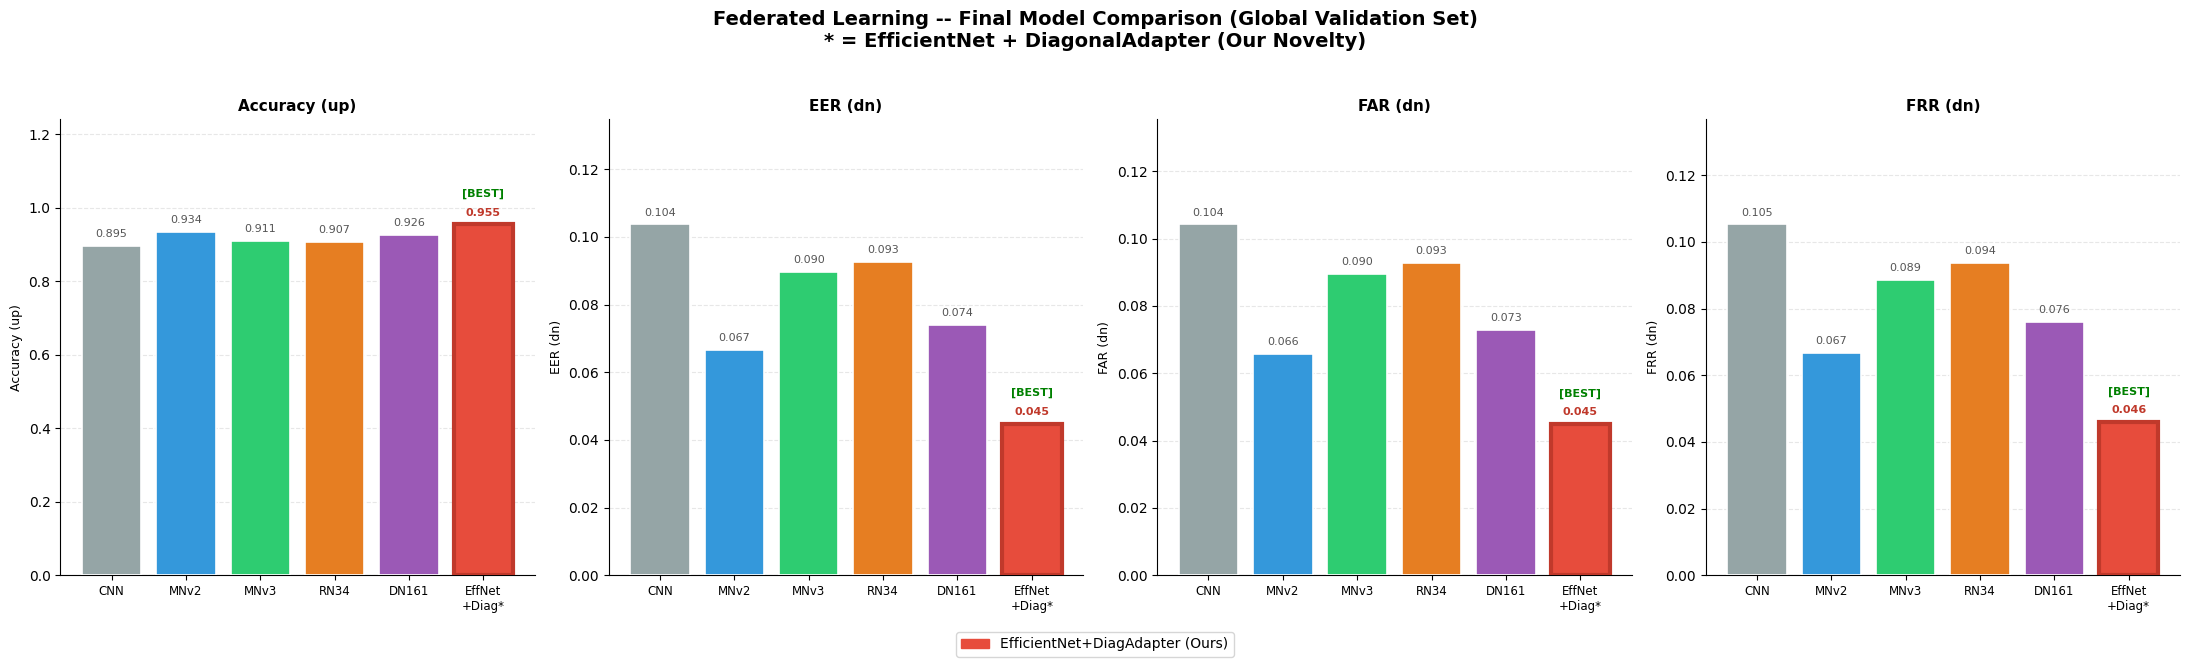

✅ Figure 1 saved.


In [ ]:
short = {
    'CNN': 'CNN', 'MobileNetV2': 'MNv2', 'MobileNetV3': 'MNv3',
    'ResNet-34': 'RN34', 'DenseNet-161': 'DN161',
    'EfficientNet+DiagAdapter': 'EffNet\n+Diag*',
}

fig1, axes1 = plt.subplots(1, 4, figsize=(22, 6))
fig1.suptitle(
    'Federated Learning -- Final Model Comparison (Global Validation Set)\n'
    '* = EfficientNet + DiagonalAdapter (Our Novelty)',
    fontsize=14, fontweight='bold', y=1.03
)

mcfg = [
    ('accuracy', 'Accuracy (up)', True,  '#2ecc71'),
    ('eer',      'EER (dn)',      False, '#e74c3c'),
    ('far',      'FAR (dn)',      False, '#e67e22'),
    ('frr',      'FRR (dn)',      False, '#9b59b6'),
]

for ax, (mkey, mlabel, higher, _) in zip(axes1, mcfg):
    vals   = [all_results[n]['global_after'][mkey] for n in MODEL_NAMES]
    colors = [MODEL_REGISTRY[n]['color'] for n in MODEL_NAMES]
    nidx   = MODEL_NAMES.index(NOVELTY_MODEL)

    bars = ax.bar(range(len(MODEL_NAMES)), vals, color=colors,
                  edgecolor='white', linewidth=1.2, zorder=3)
    bars[nidx].set_edgecolor('#c0392b'); bars[nidx].set_linewidth(3)

    for i, (b, v) in enumerate(zip(bars, vals)):
        ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8,
                fontweight='bold' if i == nidx else 'normal',
                color='#c0392b' if i == nidx else '#555')

    best_idx = int(np.argmax(vals)) if higher else int(np.argmin(vals))
    ax.text(best_idx, vals[best_idx] + max(vals)*0.08, '[BEST]',
            ha='center', fontsize=8, color='green', fontweight='bold')

    ax.set_xticks(range(len(MODEL_NAMES)))
    ax.set_xticklabels([short[n] for n in MODEL_NAMES], fontsize=8.5)
    ax.set_title(mlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(mlabel, fontsize=9)
    ax.grid(axis='y', alpha=0.3, ls='--', zorder=0)
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, max(vals) * 1.3)

patch = mpatches.Patch(color=MODEL_REGISTRY[NOVELTY_MODEL]['color'],
                       label='EfficientNet+DiagAdapter (Ours)')
fig1.legend(handles=[patch], loc='lower center', bbox_to_anchor=(0.5, -0.06), fontsize=10)
plt.tight_layout()
plt.savefig('fig1_model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved.')

## 📊 Cell 14 — Figure 2: Before vs After FL — All Models

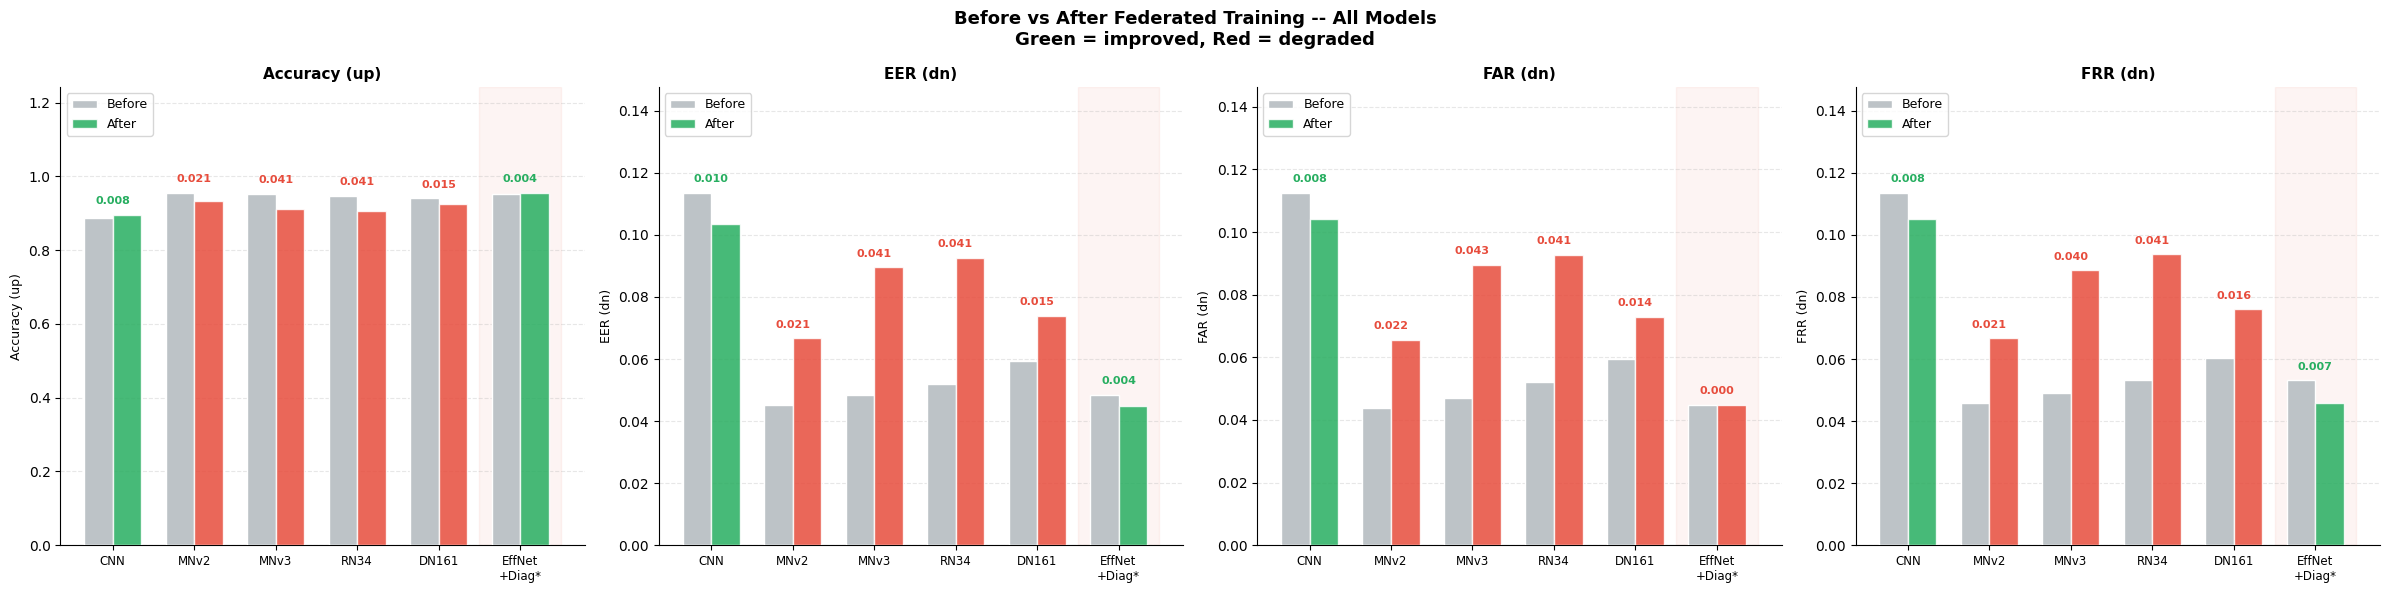

✅ Figure 2 saved.


In [ ]:
fig2, axes2 = plt.subplots(1, 4, figsize=(24, 6))
fig2.suptitle('Before vs After Federated Training -- All Models\n'
              'Green = improved, Red = degraded',
              fontsize=13, fontweight='bold')

for ax, (mkey, mlabel, higher) in zip(axes2, [
    ('accuracy', 'Accuracy (up)', True),
    ('eer',      'EER (dn)',      False),
    ('far',      'FAR (dn)',      False),
    ('frr',      'FRR (dn)',      False),
]):
    x       = np.arange(len(MODEL_NAMES))
    bw      = 0.35
    befores = [all_results[n]['global_before'][mkey] for n in MODEL_NAMES]
    afters  = [all_results[n]['global_after'][mkey]  for n in MODEL_NAMES]

    ax.bar(x - bw/2, befores, bw, label='Before', color='#bdc3c7', edgecolor='white', zorder=3)
    after_colors = ['#27ae60' if ((higher and a > b) or (not higher and a < b))
                    else '#e74c3c' for b, a in zip(befores, afters)]
    ax.bar(x + bw/2, afters, bw, label='After', color=after_colors, edgecolor='white',
           alpha=0.85, zorder=3)

    for i, (b, a) in enumerate(zip(befores, afters)):
        improved = (higher and a > b) or (not higher and a < b)
        arrow = 'up' if a > b else 'dn'
        color = '#27ae60' if improved else '#e74c3c'
        ax.text(x[i], max(b, a) + max(befores + afters)*0.03,
                f'{abs(a-b):.3f}', ha='center', fontsize=8, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([short[n] for n in MODEL_NAMES], fontsize=8.5)
    ax.set_title(mlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(mlabel, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, ls='--', zorder=0)
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, max(befores + afters) * 1.3)

    nidx = MODEL_NAMES.index(NOVELTY_MODEL)
    ax.axvspan(nidx - 0.5, nidx + 0.5, alpha=0.06, color='#e74c3c', zorder=0)

plt.tight_layout()
plt.savefig('fig2_before_after_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved.')

## 📡 Cell 15 — Figure 3: Radar Chart — Model Comparison

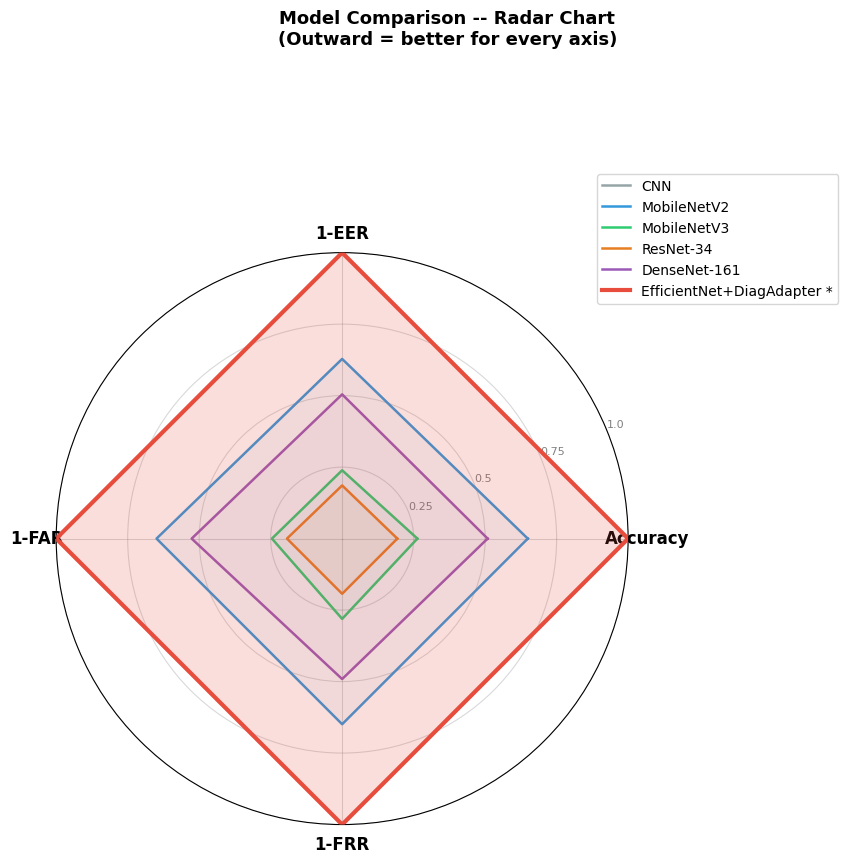

✅ Figure 3 saved.


In [ ]:
radar_keys    = ['accuracy', 'eer', 'far', 'frr']
radar_labels  = ['Accuracy', '1-EER', '1-FAR', '1-FRR']
is_higher     = [True, False, False, False]

raw_vals = {n: [all_results[n]['global_after'][m] for m in radar_keys] for n in MODEL_NAMES}
col_min  = [min(raw_vals[n][i] for n in MODEL_NAMES) for i in range(len(radar_keys))]
col_max  = [max(raw_vals[n][i] for n in MODEL_NAMES) for i in range(len(radar_keys))]

def norm(val, lo, hi, higher):
    if hi == lo: return 0.5
    n = (val - lo) / (hi - lo)
    return n if higher else 1 - n

scores = {n: [norm(raw_vals[n][i], col_min[i], col_max[i], is_higher[i])
              for i in range(len(radar_keys))]
          for n in MODEL_NAMES}

N      = len(radar_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig3, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig3.suptitle('Model Comparison -- Radar Chart\n'
              '(Outward = better for every axis)',
              fontsize=13, fontweight='bold', y=1.02)

for n in MODEL_NAMES:
    vals   = scores[n] + scores[n][:1]
    color  = MODEL_REGISTRY[n]['color']
    is_nov = (n == NOVELTY_MODEL)
    ax.plot(angles, vals, color=color, lw=3.0 if is_nov else 1.8,
            label=f'{n} *' if is_nov else n, zorder=5 if is_nov else 2)
    ax.fill(angles, vals, color=color, alpha=0.18 if is_nov else 0.05,
            zorder=5 if is_nov else 2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=8, color='grey')
ax.grid(color='grey', alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('fig3_radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved.')

## 📈 Cell 16 — Re-train Combined Model for Detailed FL Curves

The combined model (EfficientNet + DiagonalAdapter) is retrained for `FL_ROUNDS` rounds to produce detailed per-client training curves.

In [ ]:
print(f'Re-training {NOVELTY_MODEL} for {FL_ROUNDS} rounds (detailed FL analysis)...\n')

combined_model = build_model(NOVELTY_MODEL)
history        = {c: {'accuracy':[],'loss':[],'eer':[],'far':[],'frr':[]} for c in CLIENT_NAMES}
best_avg_eer   = float('inf'); no_improve_count = 0

g_before_combined = evaluate_model(combined_model, global_val_loader)
print(f'Baseline -> Acc:{g_before_combined["accuracy"]:.4f} EER:{g_before_combined["eer"]:.4f}')

for i, cname in enumerate(CLIENT_NAMES):
    m = evaluate_model(combined_model, client_val_loaders[i])
    for k in m: history[cname][k].append(m[k])

rounds_bar = tqdm(range(1, FL_ROUNDS + 1), desc='Combined FL', ncols=80)
for rnd in rounds_bar:
    c_weights, c_sizes = [], []
    for i, cname in enumerate(CLIENT_NAMES):
        w = client_train(combined_model, client_train_loaders[i], LOCAL_EPOCHS, LR_ADAPTER, i)
        c_weights.append(w); c_sizes.append(len(client_train_loaders[i].dataset))
        local = copy.deepcopy(combined_model); local.load_state_dict(w)
        m = evaluate_model(local, client_val_loaders[i])
        for k in m: history[cname][k].append(m[k])
    combined_model.load_state_dict(federated_average(c_weights, c_sizes))
    avg_eer = np.mean([history[c]['eer'][-1] for c in CLIENT_NAMES])
    rounds_bar.set_postfix(avg_eer=f'{avg_eer:.4f}')
    if best_avg_eer - avg_eer > EARLY_STOP_MIN_DELTA:
        best_avg_eer = avg_eer; no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOP_PATIENCE:
            tqdm.write(f'Early stop at round {rnd}'); break

g_after_combined = evaluate_model(combined_model, global_val_loader)
actual_rounds    = len(history[CLIENT_NAMES[0]]['accuracy']) - 1
rounds_arr       = np.arange(0, actual_rounds + 1)
round_labels     = ['Base'] + [str(r) for r in range(1, actual_rounds + 1)]

print(f'\nFinal -> Acc:{g_after_combined["accuracy"]:.4f} EER:{g_after_combined["eer"]:.4f} '
      f'FAR:{g_after_combined["far"]:.4f} ({actual_rounds} rounds)')

Re-training EfficientNet+DiagAdapter for 10 rounds (detailed FL analysis)...

Loaded pretrained weights for efficientnet-b0
  [EfficientNet+DiagAdapter]  total=4,008,828  trainable=1,280
Baseline -> Acc:0.9510 EER:0.0484


Combined FL:  60%|████████▍     | 6/10 [15:04<10:02, 150.74s/it, avg_eer=0.0547]


Early stop at round 7

Final -> Acc:0.9490 EER:0.0505 FAR:0.0500 (7 rounds)


## 📈 Cell 16a — Figure 4: Per-Client FL Curves — Combined Model

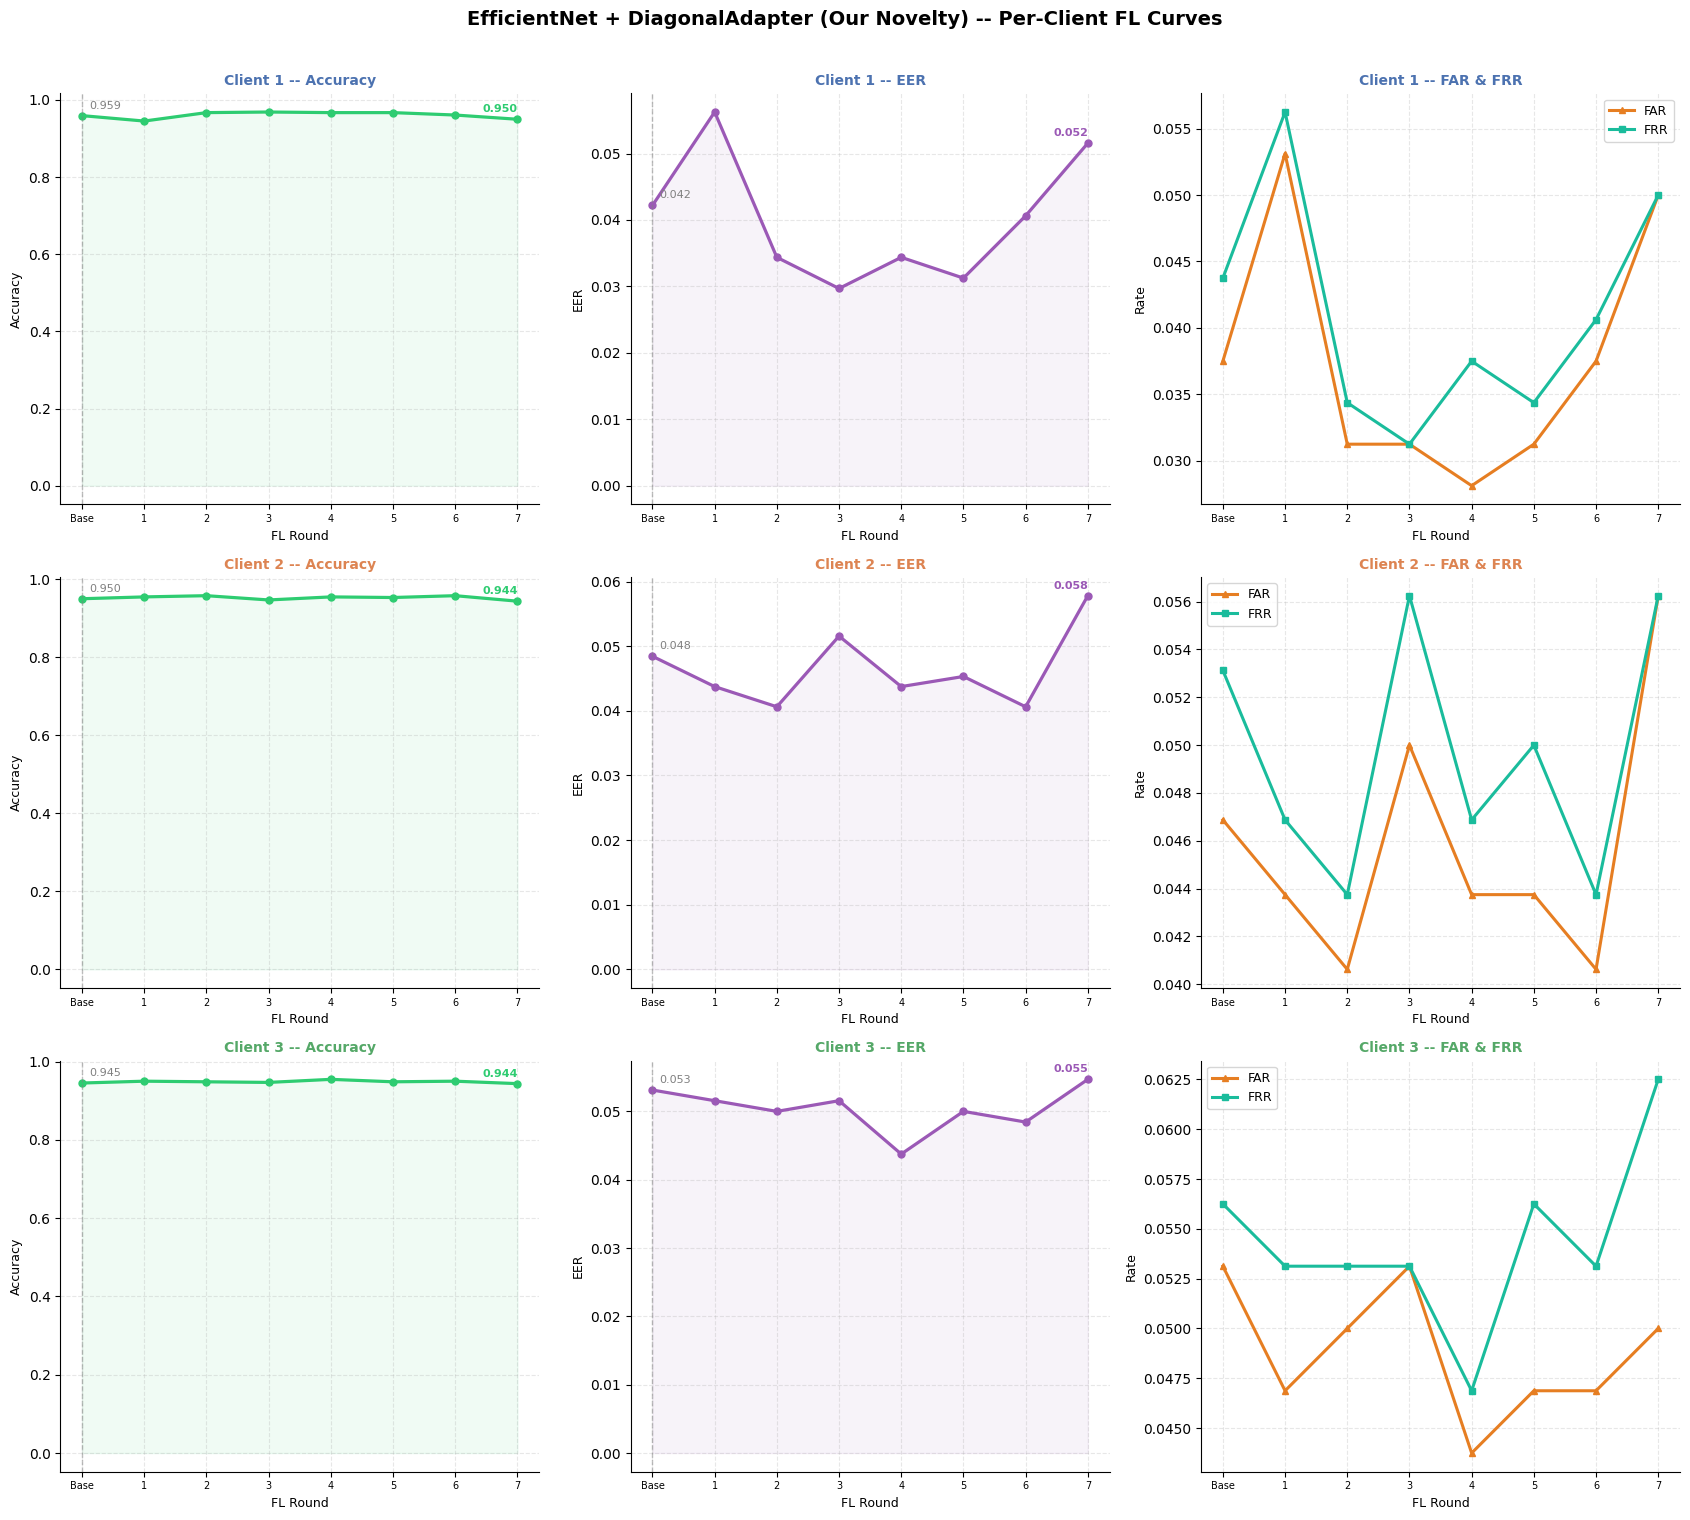

✅ Figure 4 saved.


In [ ]:
fig4, axes4 = plt.subplots(NUM_CLIENTS, 3, figsize=(17, 5 * NUM_CLIENTS))
if NUM_CLIENTS == 1: axes4 = axes4[np.newaxis, :]
fig4.suptitle('EfficientNet + DiagonalAdapter (Our Novelty) -- Per-Client FL Curves',
              fontsize=14, fontweight='bold', y=1.01)

for row, (cname, ccolor) in enumerate(zip(CLIENT_NAMES, CLIENT_COLORS)):
    data = history[cname]
    for col, (mkey, mlabel, mcolor) in enumerate([
        ('accuracy', 'Accuracy', '#2ecc71'),
        ('eer',      'EER',      '#9b59b6')]):
        ax  = axes4[row][col]; vals = data[mkey]
        ax.plot(rounds_arr, vals, color=mcolor, lw=2.3, marker='o', ms=5)
        ax.axvline(x=0, color='grey', ls='--', alpha=0.5, lw=1)
        ax.fill_between(rounds_arr, vals, alpha=0.07, color=mcolor)
        ax.set_title(f'{cname} -- {mlabel}', fontsize=10, fontweight='bold', color=ccolor)
        ax.set_xlabel('FL Round', fontsize=9); ax.set_ylabel(mlabel, fontsize=9)
        ax.set_xticks(rounds_arr); ax.set_xticklabels(round_labels, fontsize=7)
        ax.grid(True, alpha=0.3, ls='--'); ax.spines[['top','right']].set_visible(False)
        ax.annotate(f'{vals[0]:.3f}', (0, vals[0]), xytext=(5,5),
                    textcoords='offset points', fontsize=8, color='grey')
        ax.annotate(f'{vals[-1]:.3f}', (actual_rounds, vals[-1]), xytext=(-25,5),
                    textcoords='offset points', fontsize=8, color=mcolor, fontweight='bold')
    ax4 = axes4[row][2]
    ax4.plot(rounds_arr, data['far'], color='#e67e22', lw=2.2, marker='^', ms=5, label='FAR')
    ax4.plot(rounds_arr, data['frr'], color='#1abc9c', lw=2.2, marker='s', ms=5, label='FRR')
    ax4.set_title(f'{cname} -- FAR & FRR', fontsize=10, fontweight='bold', color=ccolor)
    ax4.set_xlabel('FL Round', fontsize=9); ax4.set_ylabel('Rate', fontsize=9)
    ax4.set_xticks(rounds_arr); ax4.set_xticklabels(round_labels, fontsize=7)
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, ls='--')
    ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_combined_per_client_curves.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Figure 4 saved.')

## 📊 Cell 17 — Figure 5: Before vs After — Combined Model (All Clients)

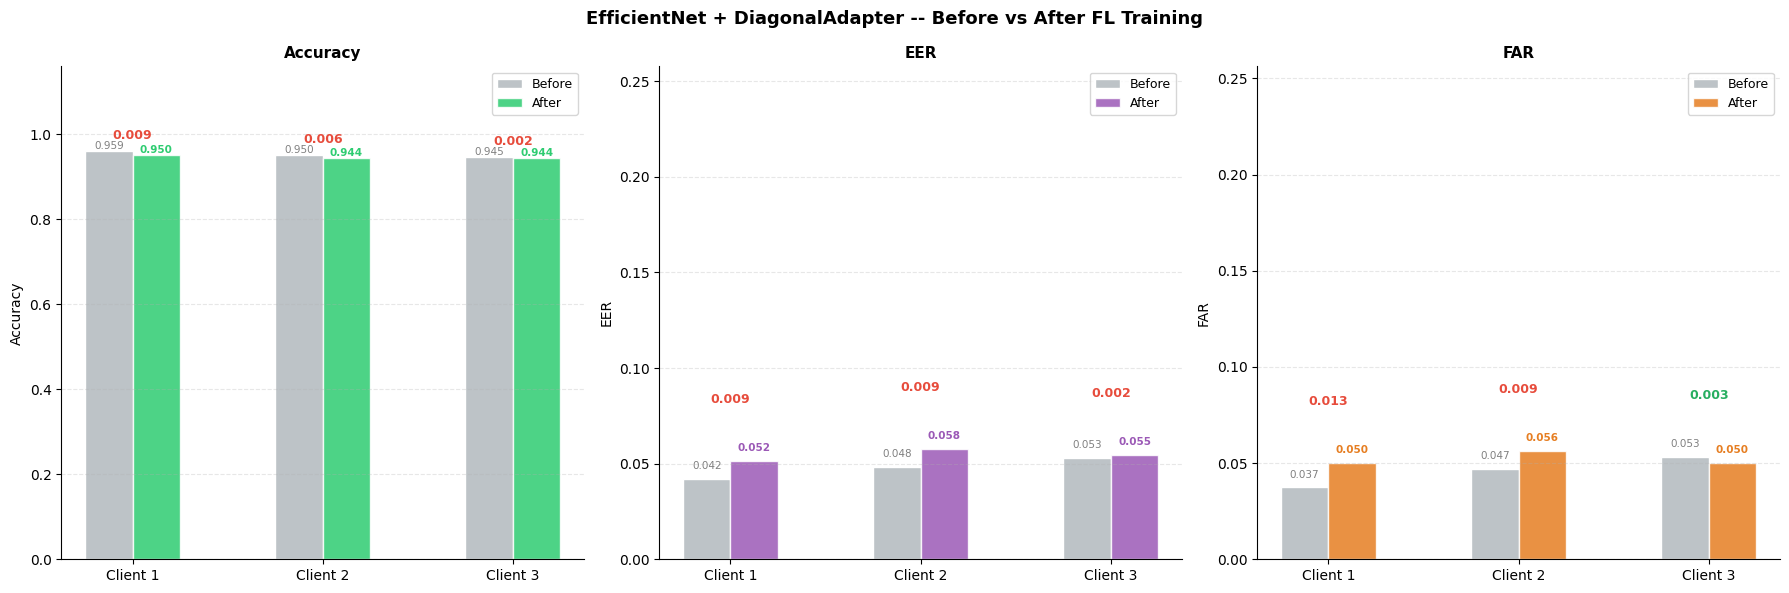

✅ Figure 5 saved.


In [ ]:
fig5, axes5 = plt.subplots(1, 3, figsize=(18, 6))
fig5.suptitle('EfficientNet + DiagonalAdapter -- Before vs After FL Training',
              fontsize=13, fontweight='bold')
bw = 0.25; x = np.arange(NUM_CLIENTS)

for idx, (mkey, mlabel, higher, mcolor) in enumerate([
    ('accuracy', 'Accuracy', True,  '#2ecc71'),
    ('eer',      'EER',      False, '#9b59b6'),
    ('far',      'FAR',      False, '#e67e22')]):
    ax = axes5[idx]
    bv = [history[c][mkey][0]  for c in CLIENT_NAMES]
    av = [history[c][mkey][-1] for c in CLIENT_NAMES]
    ax.bar(x-bw/2, bv, bw, label='Before', color='#bdc3c7', edgecolor='white')
    ax.bar(x+bw/2, av, bw, label='After',  color=mcolor,    edgecolor='white', alpha=0.85)
    for i, (b, a) in enumerate(zip(bv, av)):
        improved = (higher and a > b) or (not higher and a < b)
        color    = '#27ae60' if improved else '#e74c3c'
        ax.text(i, max(b,a)+0.03, f'{abs(a-b):.3f}', ha='center',
                fontsize=9, color=color, fontweight='bold')
        ax.text(i-bw/2, b+0.005, f'{b:.3f}', ha='center', fontsize=7.5, color='gray')
        ax.text(i+bw/2, a+0.005, f'{a:.3f}', ha='center', fontsize=7.5,
                color=mcolor, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(CLIENT_NAMES, fontsize=10)
    ax.set_title(mlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(mlabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, max(max(bv), max(av)) + 0.2)

plt.tight_layout()
plt.savefig('fig5_combined_before_after.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Figure 5 saved.')

## 🔍 Cell 18 — Figure 6: All Clients Overlay — Combined Model

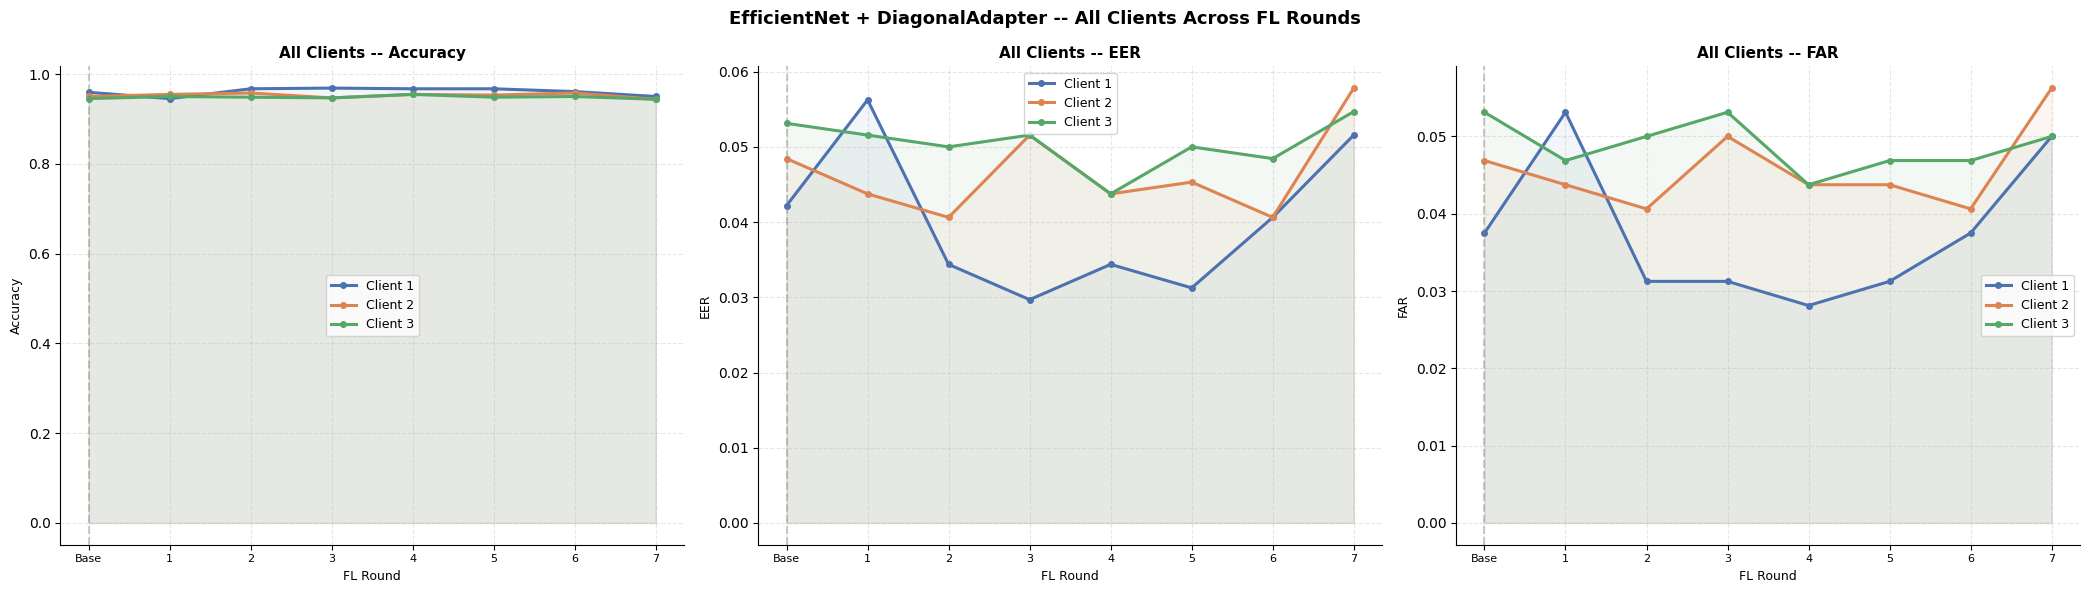

✅ Figure 6 saved.


In [ ]:
fig6, axes6 = plt.subplots(1, 3, figsize=(21, 6))
fig6.suptitle('EfficientNet + DiagonalAdapter -- All Clients Across FL Rounds',
              fontsize=13, fontweight='bold')

for idx, (mkey, mlabel) in enumerate([
    ('accuracy', 'Accuracy'), ('eer', 'EER'), ('far', 'FAR')]):
    ax = axes6[idx]
    for cname, ccolor in zip(CLIENT_NAMES, CLIENT_COLORS):
        vals = history[cname][mkey]
        ax.plot(rounds_arr, vals, color=ccolor, lw=2.2, marker='o', ms=4, label=cname)
        ax.fill_between(rounds_arr, vals, alpha=0.07, color=ccolor)
    ax.set_xlabel('FL Round', fontsize=9); ax.set_ylabel(mlabel, fontsize=9)
    ax.set_title(f'All Clients -- {mlabel}', fontsize=11, fontweight='bold')
    ax.set_xticks(rounds_arr); ax.set_xticklabels(round_labels, fontsize=8)
    ax.axvline(x=0, color='grey', ls='--', alpha=0.4)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig6_combined_all_clients.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Figure 6 saved.')

## 💾 Cell 19 — Save Models & Download All Results

In [ ]:
import json
from google.colab import files

torch.save({
    'model_state_dict'   : combined_model.state_dict(),
    'fl_rounds_completed': actual_rounds,
    'embedding_dim'      : 1280,
    'history'            : history,
    'global_before'      : g_before_combined,
    'global_after'       : g_after_combined,
}, 'fl_efficientnet_diagadapter.pth')
print('✅ Combined model saved.')

export = {}
for name in MODEL_NAMES:
    r = all_results[name]
    export[name] = {
        'global_before': r['global_before'],
        'global_after' : r['global_after'],
        'actual_rounds': r['actual_rounds'],
    }
with open('model_comparison_results.json', 'w') as f:
    json.dump(export, f, indent=2)
print('✅ Comparison results saved.')

print('\n' + '='*70)
print('  FINAL RANKING -- Global Validation Set (by EER asc)')
print('='*70)
print(f"{'Model':<34} {'Accuracy':>10} {'EER':>8} {'FAR':>8} {'FRR':>8}")
print('-'*70)
ranked_final = sorted(MODEL_NAMES, key=lambda n: all_results[n]['global_after']['eer'])
medals_disp  = ['[1st]','[2nd]','[3rd]'] + ['     '] * (len(MODEL_NAMES) - 3)
for i, name in enumerate(ranked_final):
    ga  = all_results[name]['global_after']
    tag = '  <<< OUR MODEL' if name == NOVELTY_MODEL else ''
    print(f'{medals_disp[i]} {name:<29} {ga["accuracy"]:>10.4f} {ga["eer"]:>8.4f} '
          f'{ga["far"]:>8.4f} {ga["frr"]:>8.4f}{tag}')
print('='*70)

output_files = [
    'fl_efficientnet_diagadapter.pth',
    'model_comparison_results.json',
    'fig1_model_comparison_bars.png',
    'fig2_before_after_all_models.png',
    'fig3_radar_comparison.png',
    'fig4_combined_per_client_curves.png',
    'fig5_combined_before_after.png',
    'fig6_combined_all_clients.png',
]
print('\nDownloading output files...')
for fname in output_files:
    try:
        files.download(fname)
        print(f'  OK: {fname}')
    except Exception as e:
        print(f'  ERR: {fname}: {e}')

✅ Combined model saved.
✅ Comparison results saved.

  FINAL RANKING -- Global Validation Set (by EER asc)
Model                                Accuracy      EER      FAR      FRR
----------------------------------------------------------------------
[1st] EfficientNet+DiagAdapter          0.9547   0.0448   0.0448   0.0458  <<< OUR MODEL
[2nd] MobileNetV2                       0.9339   0.0667   0.0656   0.0667
[3rd] DenseNet-161                      0.9255   0.0740   0.0729   0.0760
      MobileNetV3                       0.9109   0.0896   0.0896   0.0885
      ResNet-34                         0.9068   0.0927   0.0927   0.0938
      CNN                               0.8953   0.1036   0.1042   0.1052



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: fl_efficientnet_diagadapter.pth


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  OK: fig5_combined_before_after.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: fig6_combined_all_clients.png


In [ ]:
print(f'{"="*62}')
print(f'  Per-Client Data Distribution')
print(f'{"="*62}')
for i, (split, cname) in enumerate(zip(splits, CLIENT_NAMES)):
    img_counts   = [len(imgs) for _, imgs in split]
    train_counts = [max(1, int(0.8 * n)) for n in img_counts]
    val_counts   = [n - t for n, t in zip(img_counts, train_counts)]
    print(f'\n  {cname} -- {len(split)} subjects')
    print(f'    Imgs/subject : min={min(img_counts)}  max={max(img_counts)}  '
          f'mean={sum(img_counts)/len(img_counts):.1f}')
    thin_val = sum(1 for v in val_counts if v < 2)
    if thin_val: print(f'    Subjects with <2 val images: {thin_val}/{len(split)}')
    else:        print(f'    All subjects have >=2 val images')
print(f'\n{"="*62}')

  Per-Client Data Distribution

  Client 1 -- 200 subjects
    Imgs/subject : min=10  max=10  mean=10.0
    All subjects have >=2 val images

  Client 2 -- 200 subjects
    Imgs/subject : min=10  max=10  mean=10.0
    All subjects have >=2 val images

  Client 3 -- 200 subjects
    Imgs/subject : min=10  max=10  mean=10.0
    All subjects have >=2 val images

